## Data Cleaning
- Decide how to impute null values.
- Decide how to handle outliers.
- Do you want to combine any features?
- Do you want to have interaction terms?
- Do you want to manually drop collinear features?

## Functions

In [1]:
# side by side display
def display_side_by_side(*args):
    outputs = [widgets.Output() for _ in args]

    for i, output in enumerate(outputs):
        with output:
            display(args[i])

    display(widgets.HBox(outputs))

In [2]:
# fill the numerical cols with the mean 
def fill_with_mean(df):
    num_cols = df_train.select_dtypes(include=np.number).columns
    for col in num_cols:
        df[col].fillna(df[col].mean(), inplace=True)
    return df

In [3]:
# inspect outliers funct
def inspect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    print(f"For column {column}:")
    print(f"Lower bound for outliers: {lower_bound}")
    print(f"Upper bound for outliers: {upper_bound}")

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    print(f"Number of outliers detected: {outliers.shape[0]}")
    
    return outliers

## Libraries/ Imports

In [4]:
import ipywidgets as widgets
from IPython.display import display

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

train = pd.read_csv('./data/train.csv')
test = pd.read_csv('./data/test.csv') 

In [5]:
#rename columns to snake case
train.columns = train.columns.str.lower().str.replace(' ', '_')
test.columns = test.columns.str.lower().str.replace(' ', '_')

## DF info

In [6]:
train.head()

,id,pid,ms_subclass,ms_zoning,lot_frontage,lot_area,street,alley,lot_shape,land_contour,...,screen_porch,pool_area,pool_qc,fence,misc_feature,misc_val,mo_sold,yr_sold,sale_type,saleprice
0,109,533352170,60,RL,NaN,13517,Pave,NaN,IR1,Lvl,...,0,0,NaN,NaN,NaN,0,3,2010,WD,130500
1,544,531379050,60,RL,43.0,11492,Pave,NaN,IR1,Lvl,...,0,0,NaN,NaN,NaN,0,4,2009,WD,220000
2,153,535304180,20,RL,68.0,7922,Pave,NaN,Reg,Lvl,...,0,0,NaN,NaN,NaN,0,1,2010,WD,109000
3,318,916386060,60,RL,73.0,9802,Pave,NaN,Reg,Lvl,...,0,0,NaN,NaN,NaN,0,4,2010,WD,174000
4,255,906425045,50,RL,82.0,14235,Pave,NaN,IR1,Lvl,...,0,0,NaN,NaN,NaN,0,3,2010,WD,138500


In [7]:
test.head()

,id,pid,ms_subclass,ms_zoning,lot_frontage,lot_area,street,alley,lot_shape,land_contour,...,3ssn_porch,screen_porch,pool_area,pool_qc,fence,misc_feature,misc_val,mo_sold,yr_sold,sale_type
0,2658,902301120,190,RM,69.0,9142,Pave,Grvl,Reg,Lvl,...,0,0,0,NaN,NaN,NaN,0,4,2006,WD
1,2718,905108090,90,RL,NaN,9662,Pave,NaN,IR1,Lvl,...,0,0,0,NaN,NaN,NaN,0,8,2006,WD
2,2414,528218130,60,RL,58.0,17104,Pave,NaN,IR1,Lvl,...,0,0,0,NaN,NaN,NaN,0,9,2006,New
3,1989,902207150,30,RM,60.0,8520,Pave,NaN,Reg,Lvl,...,0,0,0,NaN,NaN,NaN,0,7,2007,WD
4,625,535105100,20,RL,NaN,9500,Pave,NaN,IR1,Lvl,...,0,185,0,NaN,NaN,NaN,0,7,2009,WD


In [8]:
#check column difference
set(train.columns) - set(test.columns)

{'saleprice'}

In [9]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2051 entries, 0 to 2050
Data columns (total 81 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               2051 non-null   int64  
 1   pid              2051 non-null   int64  
 2   ms_subclass      2051 non-null   int64  
 3   ms_zoning        2051 non-null   object 
 4   lot_frontage     1721 non-null   float64
 5   lot_area         2051 non-null   int64  
 6   street           2051 non-null   object 
 7   alley            140 non-null    object 
 8   lot_shape        2051 non-null   object 
 9   land_contour     2051 non-null   object 
 10  utilities        2051 non-null   object 
 11  lot_config       2051 non-null   object 
 12  land_slope       2051 non-null   object 
 13  neighborhood     2051 non-null   object 
 14  condition_1      2051 non-null   object 
 15  condition_2      2051 non-null   object 
 16  bldg_type        2051 non-null   object 
 17  house_style   

In [10]:
# check for duplicates
print(train.duplicated().sum())

# check for duplicated property ID
print(train['pid'].duplicated().sum())

0
0


## Deal With Null Values

In [11]:
# check for rows with 50% or more missing values
row_threshold = len(train.columns) * 0.50
null_row_check = train[train.isnull().sum(axis=1) >= row_threshold]
print(null_row_check)

Empty DataFrame
Columns: [id, pid, ms_subclass, ms_zoning, lot_frontage, lot_area, street, alley, lot_shape, land_contour, utilities, lot_config, land_slope, neighborhood, condition_1, condition_2, bldg_type, house_style, overall_qual, overall_cond, year_built, year_remod/add, roof_style, roof_matl, exterior_1st, exterior_2nd, mas_vnr_type, mas_vnr_area, exter_qual, exter_cond, foundation, bsmt_qual, bsmt_cond, bsmt_exposure, bsmtfin_type_1, bsmtfin_sf_1, bsmtfin_type_2, bsmtfin_sf_2, bsmt_unf_sf, total_bsmt_sf, heating, heating_qc, central_air, electrical, 1st_flr_sf, 2nd_flr_sf, low_qual_fin_sf, gr_liv_area, bsmt_full_bath, bsmt_half_bath, full_bath, half_bath, bedroom_abvgr, kitchen_abvgr, kitchen_qual, totrms_abvgrd, functional, fireplaces, fireplace_qu, garage_type, garage_yr_blt, garage_finish, garage_cars, garage_area, garage_qual, garage_cond, paved_drive, wood_deck_sf, open_porch_sf, enclosed_porch, 3ssn_porch, screen_porch, pool_area, pool_qc, fence, misc_feature, misc_val, m

In [12]:
# filter object columns with null values and sort
object_nulls = train.select_dtypes(include='object').isnull().sum().sort_values(ascending=False)[lambda x: x>0]

# filter numerical columns with null values and sort 
numerical_nulls = train.select_dtypes(include=[np.number]).isnull().sum().sort_values(ascending=False)[lambda x: x>0]
display_side_by_side(numerical_nulls,object_nulls)

In [13]:
train.shape

(2051, 81)

### Numerical nulls

#### LOT
- Lot Frontage

In [14]:
# calculate correlation between 'lot_frontage' and other features
high_corr_features = train.corr()['lot_frontage'][train.corr()['lot_frontage'] > 0.3].sort_values(ascending=False)
print(high_corr_features)

lot_frontage     1.000000
lot_area         0.574024
1st_flr_sf       0.463900
gr_liv_area      0.383856
totrms_abvgrd    0.362704
garage_area      0.358457
total_bsmt_sf    0.356584
saleprice        0.341842
Name: lot_frontage, dtype: float64


In [15]:
# inspect outliers 
outliers = inspect_outliers((train.copy()), 'lot_frontage')

For column lot_frontage:
Lower bound for outliers: 25.0
Upper bound for outliers: 113.0
Number of outliers detected: 118


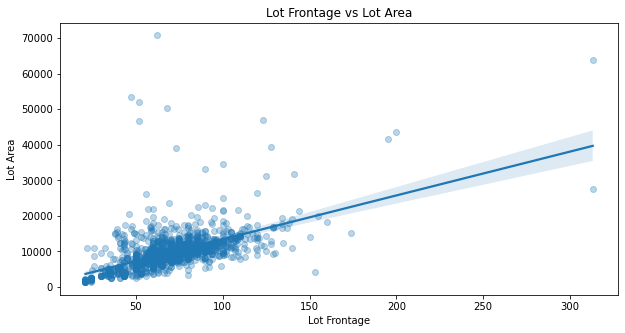

In [16]:
# Scatter plot with regression line for lot_frontage against lot_area
plt.figure(figsize=(10, 5))
sns.regplot(x='lot_frontage', y='lot_area', data=train.copy(), scatter_kws={'alpha':0.3})
plt.title('Lot Frontage vs Lot Area')
plt.xlabel('Lot Frontage')
plt.ylabel('Lot Area')
plt.show()

In [17]:
train.shape

(2051, 81)

In [18]:
# drop outliers from df
train.drop(outliers.index, inplace = True)

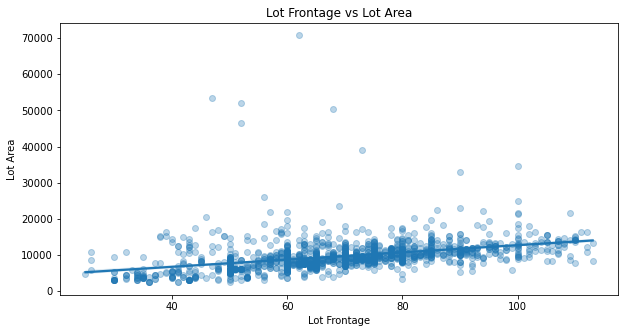

In [19]:
# Scatter plot with regression line for lot_frontage against lot_area
plt.figure(figsize=(10, 5))
sns.regplot(x='lot_frontage', y='lot_area', data=train.copy(), scatter_kws={'alpha':0.3})
plt.title('Lot Frontage vs Lot Area')
plt.xlabel('Lot Frontage')
plt.ylabel('Lot Area')
plt.show()

In [20]:
train.shape

(1933, 81)

- Lot Area

In [21]:
#inspect outliers 
outliers = inspect_outliers(train.copy(), 'lot_area')

For column lot_area:
Lower bound for outliers: 2100.5
Upper bound for outliers: 17024.5
Number of outliers detected: 82


In [22]:
# drop outliers from df
train.drop(outliers.index, inplace = True)

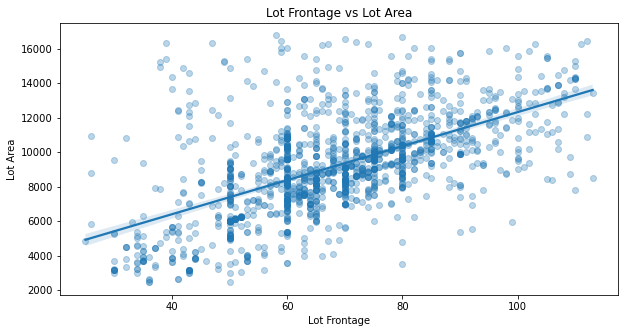

In [23]:
# Scatter plot with regression line for lot_frontage against lot_area
plt.figure(figsize=(10, 5))
sns.regplot(x='lot_frontage', y='lot_area', data=train.copy(), scatter_kws={'alpha':0.3})
plt.title('Lot Frontage vs Lot Area')
plt.xlabel('Lot Frontage')
plt.ylabel('Lot Area')
plt.show()

In [24]:
train.shape

(1851, 81)

In [25]:
# re-check correlation
high_corr_features = train.corr()['lot_frontage'][train.corr()['lot_frontage'] > 0.3].sort_values(ascending=False)
print(high_corr_features)

lot_frontage     1.000000
lot_area         0.593222
saleprice        0.402251
1st_flr_sf       0.383476
totrms_abvgrd    0.376616
gr_liv_area      0.374567
garage_area      0.350337
total_bsmt_sf    0.332217
mas_vnr_area     0.319180
garage_cars      0.315737
Name: lot_frontage, dtype: float64


### - Use LR to impute null lot frontage values

In [26]:
# Create a new DataFrame with only non-null 'lot_frontage' values (training data)
train_data = train[train['lot_frontage'].notnull()]

# Create a new DataFrame with only null 'lot_frontage' values (test data for imputation)
test_data = train[train['lot_frontage'].isnull()]

# Split the training data into features and target
X_train = train_data[['lot_area']]
y_train = train_data['lot_frontage']

# Split the test data into features (lot_area) for prediction
X_test = test_data[['lot_area']]

In [27]:
# Split the training data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Create and fit the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [28]:
# Save the original lot_frontage data before imputation
original_lot_frontage = train['lot_frontage'].copy()

In [29]:
# Predict the missing values in the test data using the fitted model
lot_frontage_imputed = model.predict(X_test)

# Replace the missing values in the original DataFrame with the imputed values
train.loc[train['lot_frontage'].isnull(), 'lot_frontage'] = lot_frontage_imputed

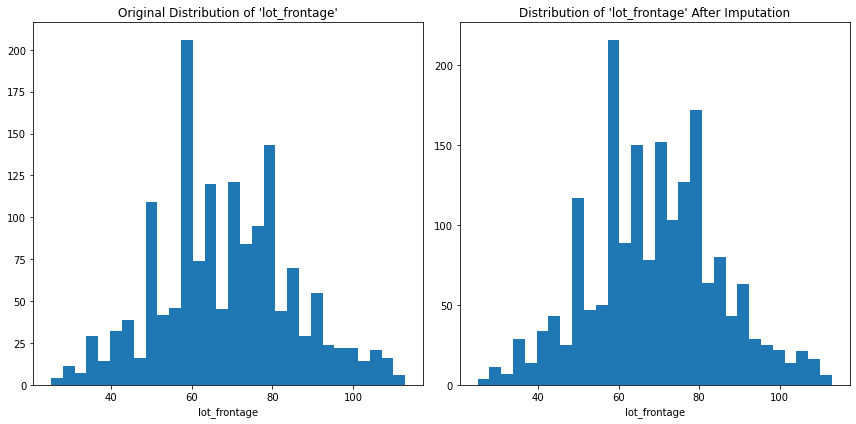

In [30]:
# Plot histograms
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.hist(original_lot_frontage, bins=30)
plt.title("Original Distribution of 'lot_frontage'")
plt.xlabel("lot_frontage")

plt.subplot(1, 2, 2)
plt.hist(train['lot_frontage'], bins=30)
plt.title("Distribution of 'lot_frontage' After Imputation")
plt.xlabel("lot_frontage")

plt.tight_layout()
plt.show()

### - Garage

In [31]:
# Count the number of properties with the same and different 'year_built' and 'garage_yr_blt'
year_comparison = train['year_built'].eq(train['garage_yr_blt']).value_counts()

print(f"Number of properties built with garage: {year_comparison[True]}")
print(f"Number of properties with garage built after: {year_comparison[False]}")

Number of properties built with garage: 1396
Number of properties with garage built after: 455


In [32]:
# nan likely means no garage
train['garage_yr_blt'].unique()

array([1976., 1997., 1953., 2007., 1957., 2005., 1959., 1952., 1969.,
       2004., 1916., 1963., 1977., 2009., 1968., 2000., 1992., 1961.,
       1973., 1937.,   nan, 2003., 1981., 1931., 1995., 1958., 1965.,
       2006., 1978., 1954., 1935., 1951., 1996., 1999., 1920., 1955.,
       1930., 1960., 1949., 1986., 1956., 1994., 1979., 1964., 1966.,
       2001., 1972., 1939., 1962., 1927., 1948., 1967., 1993., 2010.,
       1915., 1987., 1970., 1988., 1982., 1941., 1984., 1942., 1950.,
       2002., 1975., 2008., 1974., 1998., 1900., 1938., 1985., 1923.,
       1980., 1991., 1971., 1946., 1940., 1990., 1896., 1983., 1914.,
       1945., 1921., 1925., 1926., 1936., 1932., 1947., 1929., 1910.,
       1917., 1922., 1934., 1989., 1924., 1928., 2207., 1933., 1895.,
       1919.])

In [33]:
#
train['garage_yr_blt'].fillna( 0, inplace=True)

In [34]:
train.shape

(1851, 81)

- Percentage Loss = (2051 - 1747) / 2051 * 100 ≈ 14.80%

### - Basement
- Total basement square footage

In [35]:
train['total_bsmt_sf'].isna().sum() 

1

In [36]:
train.dropna(subset=['total_bsmt_sf'], axis=0, inplace=True)

- garage

In [37]:
train['garage_cars'].fillna(0, inplace = True)

In [38]:
train['garage_area'].fillna(0, inplace=True)

### Object Nulls

In [39]:
# fill all object na values with 'None'
train[train.select_dtypes(include='object').columns] = train[train.select_dtypes(include='object').columns].fillna('None')

In [40]:
train['ms_zoning'].isna().sum()

0

## Exploratory Visualizations
- Look at distributions.
- Look at correlations.
- Look at relationships to target (scatter plots for continuous, box plots for categorical).

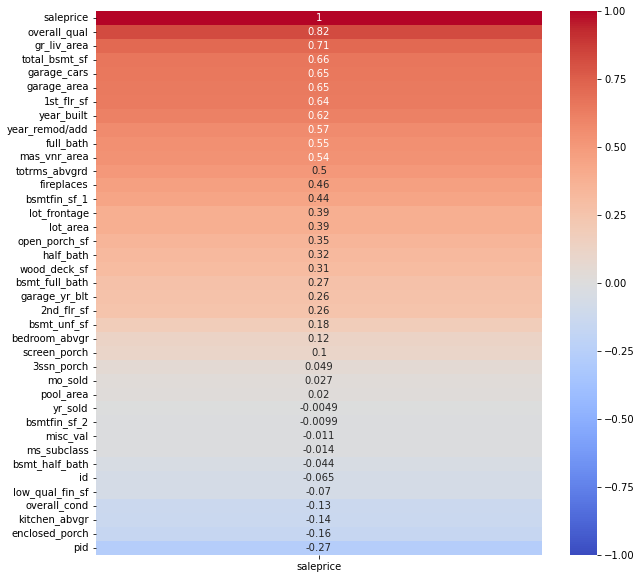

In [41]:
# heatmap of numerical cols correlation to sales price
corr = train.corr()

plt.figure(figsize=(10, 10)) 
sns.heatmap(corr[['saleprice']].sort_values(by='saleprice', ascending=False), 
            vmin=-1,
            cmap='coolwarm',
            annot=True)
plt.show();

In [42]:
train['has_garage'] = (train['garage_yr_blt'] != 0).astype(int)
test['has_garage'] = (test['garage_yr_blt'] != 0).astype(int)

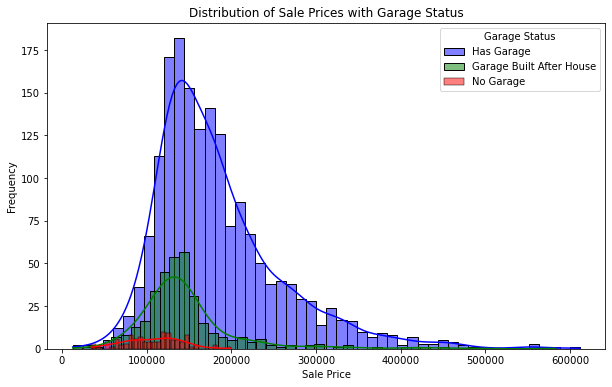

In [44]:
# Create a new DataFrame for houses with garage built after the house
houses_with_garage_after_house = train[train['garage_yr_blt'] > train['year_built']]

# Create histograms to visualize the distribution between having a garage and sale price
plt.figure(figsize=(10, 6))

# Histogram for houses with a garage
sns.histplot(data=train[train['has_garage'] == 1], 
             x='saleprice', 
             color='blue', 
             bins=50, 
             kde=True, 
             label='Has Garage')

# Histogram for houses with a garage built after the house
sns.histplot(data=houses_with_garage_after_house, 
             x='saleprice',
             color='green', 
             bins = 50, 
             kde=True, 
             label='Garage Built After House')

# Histogram for houses without a garage
sns.histplot(data=train[train['has_garage'] == 0], 
             x='saleprice', 
             color='red', 
             bins= 30, 
             kde=True, 
             label='No Garage')

plt.xlabel('Sale Price')
plt.ylabel('Frequency')
plt.title('Distribution of Sale Prices with Garage Status')
plt.legend(title='Garage Status')
plt.show()

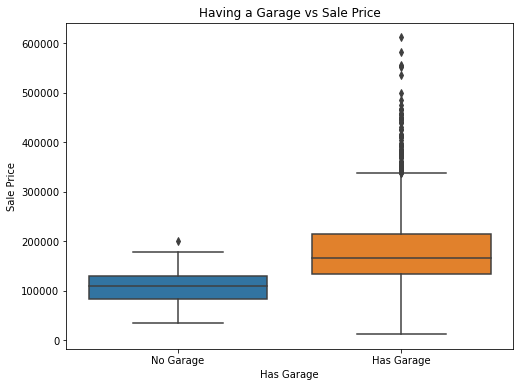

In [45]:
# inspect the sale price of houses with and without garages
plt.figure(figsize=(8, 6))
sns.boxplot(x='has_garage', 
            y='saleprice', 
            data=train)
plt.xlabel('Has Garage')
plt.ylabel('Sale Price')
plt.title('Having a Garage vs Sale Price')
plt.xticks([0, 1], ['No Garage', 'Has Garage'])
plt.show()

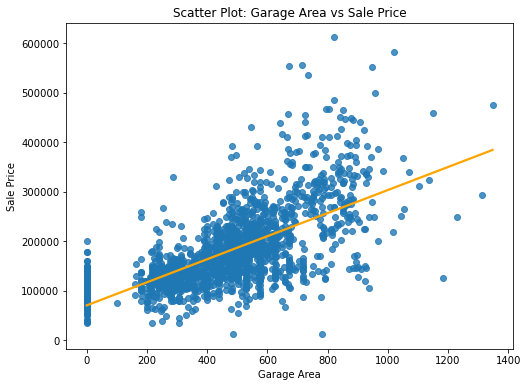

In [46]:
# correlation between garage area and sale price
plt.figure(figsize=(8, 6))
sns.regplot(data=train, 
            x='garage_area', 
            y='saleprice',
            ci=None,line_kws = {'color': 'orange'}
           )
plt.xlabel('Garage Area')
plt.ylabel('Sale Price')
plt.title('Scatter Plot: Garage Area vs Sale Price')
plt.show()

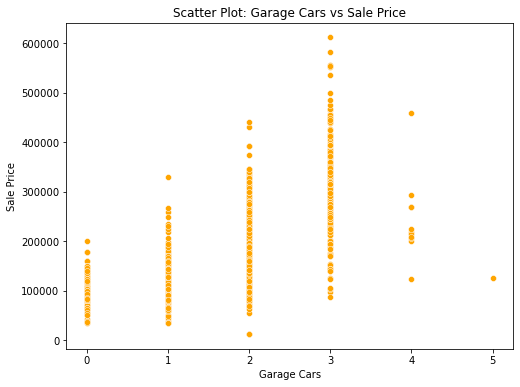

In [47]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=train, x='garage_cars', y='saleprice', color='orange')
plt.xticks(np.arange(min(train['garage_cars']), max(train['garage_cars'])+1, 1))
plt.xlabel('Garage Cars')
plt.ylabel('Sale Price')
plt.title('Scatter Plot: Garage Cars vs Sale Price')
plt.show()

In [48]:
num_zero_garage_area = (train['garage_area'] == 0).sum()
print(f"Number of houses with 'garage_area' value of 0: {num_zero_garage_area}")

num_zeros_has_garage = (train['has_garage'] == 0).sum()
print(f"Number of houses with no garage: {num_zeros_has_garage}")

Number of houses with 'garage_area' value of 0: 104
Number of houses with no garage: 104


### Garage Features vs Sale Price

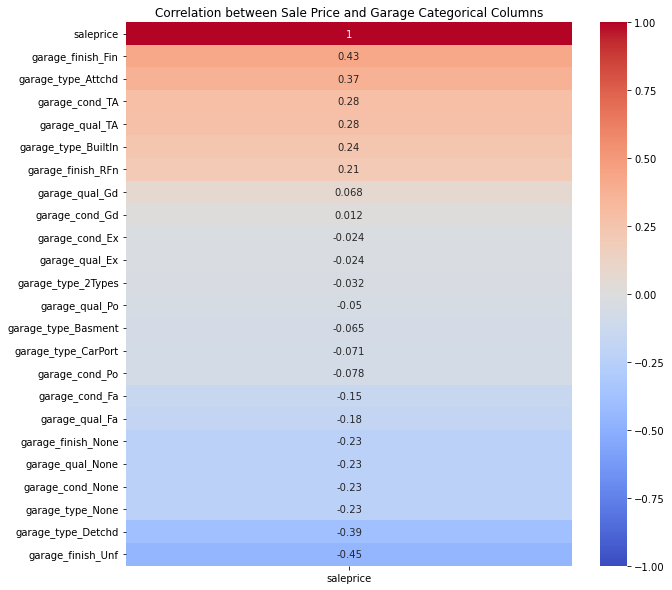

In [49]:
# Extract garage categorical columns
garage_categorical_cols = ['garage_type', 'garage_finish', 'garage_qual', 'garage_cond']

# One-hot encode the garage categorical columns
garage_encoded = pd.get_dummies(train[garage_categorical_cols])

# Combine the one-hot encoded columns with the 'saleprice' column
combined_data = pd.concat([train['saleprice'], 
                          garage_encoded], 
                          axis=1)

# Calculate the correlation matrix
corr_matrix = combined_data.corr()

# Sort the columns based on the correlation with 'saleprice'
sorted_corr = corr_matrix[['saleprice']].sort_values(by='saleprice', ascending=False)

# Create the heatmap
plt.figure(figsize=(10, 10)) 
sns.heatmap(sorted_corr, 
            vmin=-1, 
            cmap='coolwarm', 
            annot=True)
plt.title('Correlation between Sale Price and Garage Categorical Columns')
plt.show()

In [ ]:
# List of categorical garage columns
garage_categorical_cols = ['garage_type', 'garage_finish', 'garage_qual', 'garage_cond']

# Create individual box plots for each garage categorical column
for col in garage_categorical_cols:
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=train, x=col, y='saleprice')
    plt.xlabel(col)
    plt.ylabel('Sale Price')
    plt.title(f'Box Plot: {col} vs Sale Price')
    plt.show()

### Zoning, Garage, Saleprice

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=train, x='ms_zoning', y='saleprice', hue='has_garage')
plt.xlabel('Zoning Classification')
plt.ylabel('Sale Price')
plt.title('Sale Price based on Zoning and Garage Presence')
plt.legend(title='Has Garage', labels=['No', 'Yes'])
plt.xticks(rotation=45)
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=train, x='ms_zoning', y='saleprice', hue='has_garage', errorbar=None)
plt.xlabel('Zoning Classification')
plt.ylabel('Mean Sale Price')
plt.title('Mean Sale Price based on Zoning and Garage Presence')
plt.legend(title='Has Garage', labels=['No', 'Yes'])
plt.xticks(rotation=45)
plt.show()

Did homes that remodeled add a garage and if so what was the effect on the price?

In [ ]:
# Create a new column 'garage_during_remodel' to indicate if the garage was added during remodeling
train['garage_during_remodel'] = (train['year_remod/add'] == train['garage_yr_blt'])
test['garage_during_remodel'] = (test['year_remod/add'] == test['garage_yr_blt'])
# Display the count of houses where the garage was added during remodeling or not
print(train['garage_during_remodel'].value_counts())

In [ ]:
# Filter the DataFrame for houses where the garage was added during remodeling and houses where it wasn't
garage_during_remodel_df = train[train['garage_during_remodel']]
garage_not_during_remodel_df = train[~train['garage_during_remodel']]

# Create a figure with two subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# Plot the histogram of sale prices for houses with garage added during remodeling
axs[0].hist(garage_during_remodel_df['saleprice'], bins=30)
axs[0].set_xlabel('Sale Price')
axs[0].set_ylabel('Frequency')
axs[0].set_title('Sale Prices: Garage Added During Remodeling')

# Plot the histogram of sale prices for houses without garage added during remodeling
axs[1].hist(garage_not_during_remodel_df['saleprice'], bins=30)
axs[1].set_xlabel('Sale Price')
axs[1].set_title('Sale Prices: Garage Added During Remodeling')

plt.show()

In [ ]:
# Filter the DataFrame for houses that added a garage during remodeling
garage_during_remodel_df = train[train['garage_during_remodel']]

# Create a box plot to compare sale prices for each zoning category
plt.figure(figsize=(10, 6))
sns.boxplot(x='ms_zoning', y='saleprice', data=garage_during_remodel_df)
plt.xlabel('Zoning Category')
plt.ylabel('Sale Price')
plt.title('Sale Prices for Houses with Garage Added During Remodeling by Zoning Category')
plt.xticks(rotation=45)
plt.show()

In [ ]:
train.to_csv('./train_cleaned.csv', index = False)
test.to_csv('./test_cleaned.csv', index = False)